# Transverse Diffusion Templating Test

This notebook explores a templating technique for transverse diffusion, similar to the one already implemented for longitudinal diffusion. 

## Objective
Currently, transverse diffusion is handled by integrating a 2D Gaussian over a grid of spatial bins for each electron segment. This is computationally expensive and potentially redundant if we can pre-compute templates for different $\sigma_T$ values and interpolate between them.

We will:
1. Load the existing LUT.
2. Implement a transverse templating function (2D convolution with varying $\sigma_T$).
3. Compare the templated results with the current semi-analytical implementation and MC sampling.

In [1]:
import sys

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from larndsim.consts_jax import load_detector_properties, load_lut, build_params_class
from scipy.signal import convolve2d

# 1. Setup parameters
to_propagate = ('Ab', 'kb', 'long_diff', 'tran_diff')
Params_class = build_params_class(to_propagate)
params = load_detector_properties(Params_class, "src/larndsim/detector_properties/module0.yaml", 
                                "src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml")

# 2. Load LUT
lut_file = "src/larndsim/detector_properties/response_44.npy"
response_template, params = load_lut(lut_file, params)

# response_template is the *trimmed* signal window only (last signal_length ticks).
# load_lut zero-pads the raw waveform by long_diff_extent ticks before convolving,
# so the longitudinal tail never wraps around.
sig_len = params.signal_length
Nt_cum = params.response_cum.shape[-1]
# Nt_full here is the padded length: Nt_full_orig + long_diff_extent
# (= raw LUT Nt + long_diff_extent, e.g. 1891 + 20 = 1911 for response_44.npy)
Nt_full = Nt_cum + sig_len - 1

raw_response = np.load(lut_file)  # (Nx, Ny, Nt_full_orig) — full waveform, NOT padded
Nt_full_orig = raw_response.shape[-1]

# raw_lut: original unpadded LUT used by get_semi_analytical_wf / get_mc_wf.
raw_lut = raw_response

print(f"Response template shape (trimmed signal): {response_template.shape}")
print(f"Response cum shape:                       {params.response_cum.shape}")
print(f"Raw LUT shape (Nx, Ny, Nt_full_orig):     {raw_lut.shape}")
print(f"sig_len={sig_len}, Nt_full_orig={Nt_full_orig}, Nt_full_padded={Nt_full}, Nt_cum={Nt_cum}")
print(f"long_diff_extent (padding) = {params.long_diff_extent}")


/sdf/group/neutrino/pgranger/larnd-sim-jax


/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Response template shape (trimmed signal): (50, 50, 45, 45, 150)
Response cum shape:                       (50, 45, 45, 1762)
Raw LUT shape (Nx, Ny, Nt_full_orig):     (45, 45, 1891)
sig_len=150, Nt_full_orig=1891, Nt_full_padded=1911, Nt_cum=1762
long_diff_extent (padding) = 20


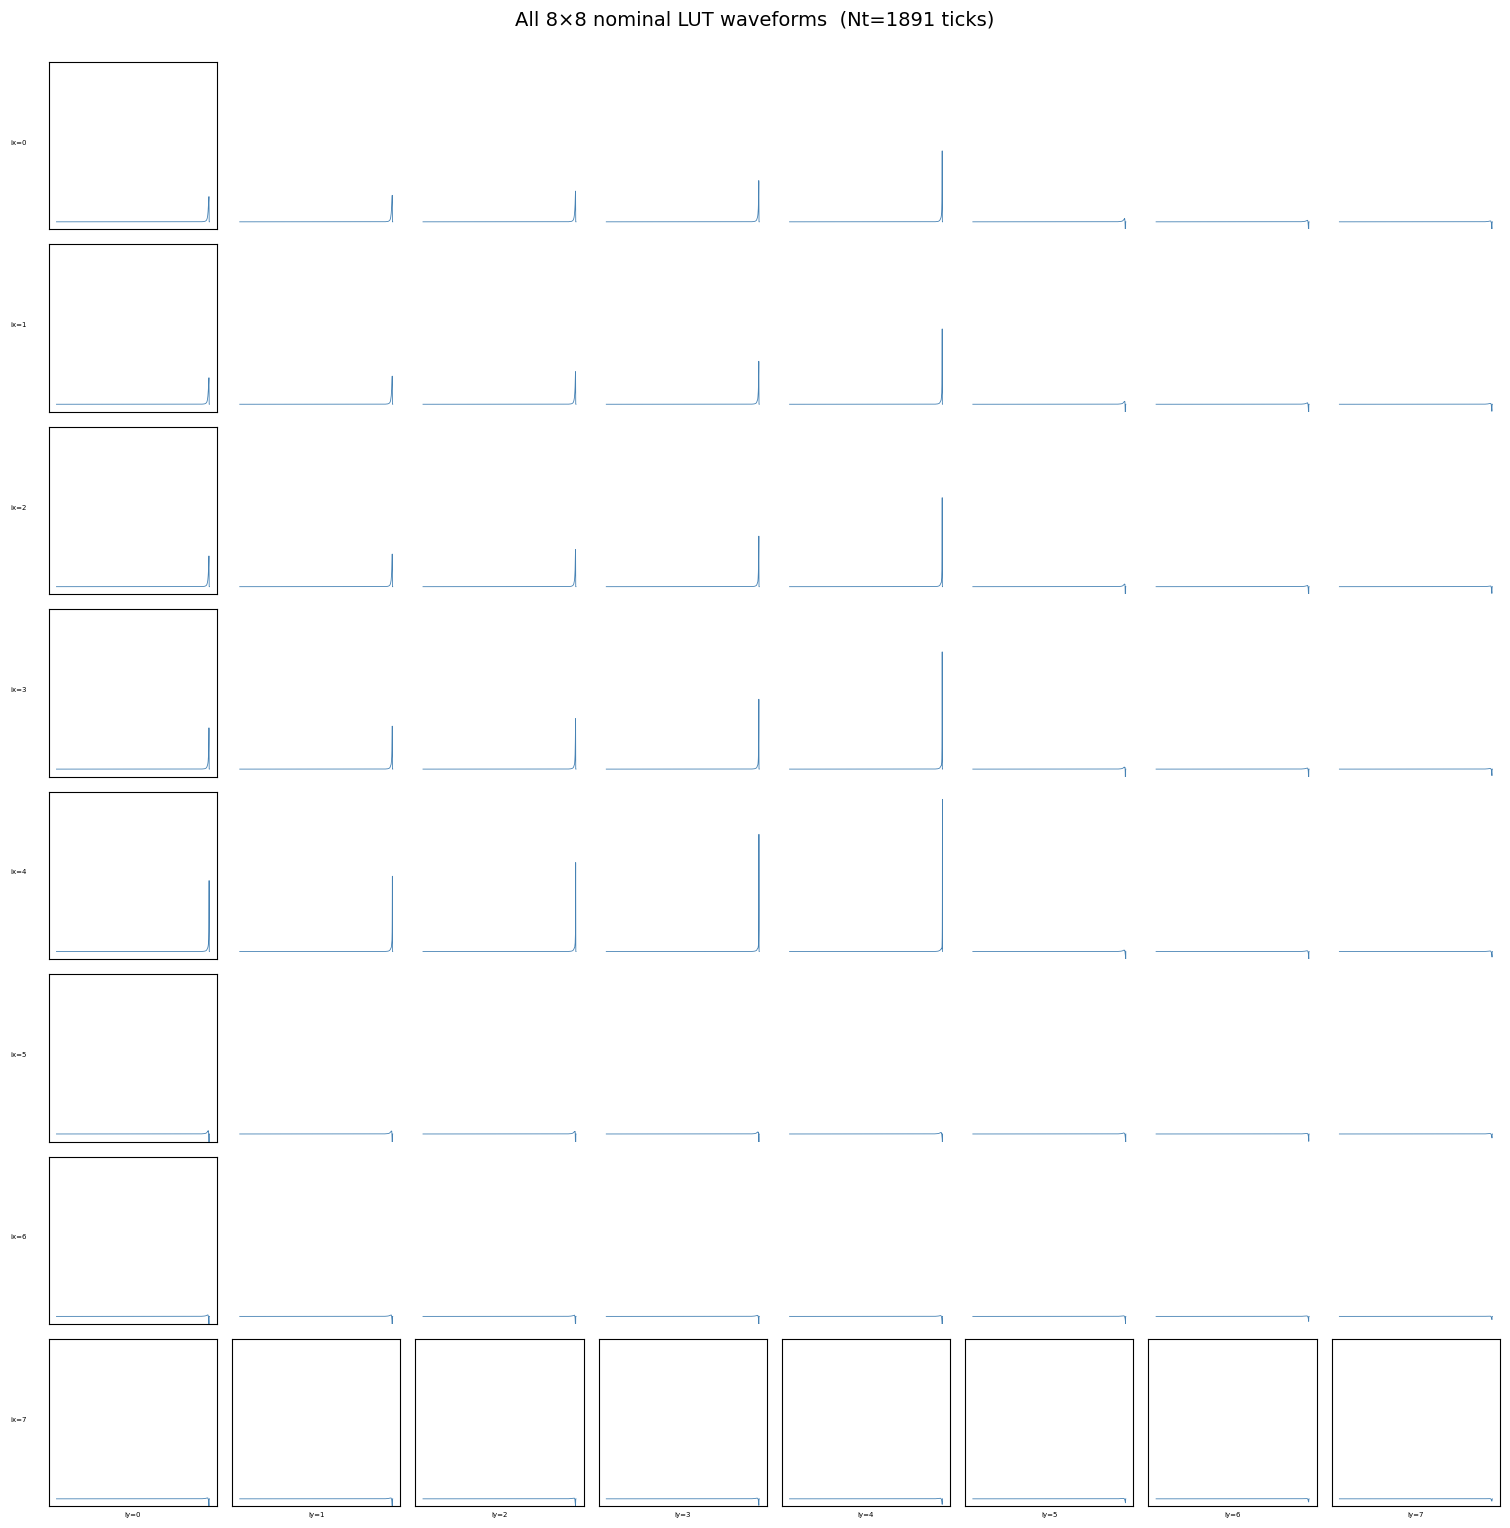

In [3]:

# Plot all Nx × Ny nominal waveforms in a grid.
# raw_lut has shape (Nx, Ny, Nt_full); each panel shows the waveform at one (ix, iy) spatial bin.

Nx, Ny, Nt_full_plot = raw_lut.shape
t_full = np.arange(Nt_full_plot)

Nx, Ny = 8, 8

fig, axes = plt.subplots(Nx, Ny,
                         figsize=(Ny * 1.9, Nx * 1.9),
                         sharex=True, sharey=True)
fig.suptitle(f"All {Nx}×{Ny} nominal LUT waveforms  (Nt={Nt_full_plot} ticks)", fontsize=14, y=1.002)

vmax = raw_lut.max()

for ix in range(Nx):
    for iy in range(Ny):
        ax = axes[ix, iy]
        ax.plot(t_full, raw_lut[ix, iy], lw=0.6, color='steelblue')
        ax.set_ylim(-0.05 * vmax, 1.05 * vmax)
        ax.axis('off')

# Add shared axis labels on the border panels only
for ix in range(Nx):
    axes[ix, 0].axis('on')
    axes[ix, 0].set_yticks([])
    axes[ix, 0].set_ylabel(f"ix={ix}", fontsize=5, rotation=0, labelpad=22)
    axes[ix, 0].tick_params(left=False, bottom=False, labelbottom=False)
for iy in range(Ny):
    axes[-1, iy].axis('on')
    axes[-1, iy].set_xticks([])
    axes[-1, iy].set_xlabel(f"iy={iy}", fontsize=5)
    axes[-1, iy].tick_params(left=False, bottom=False, labelleft=False)

plt.tight_layout()
plt.show()


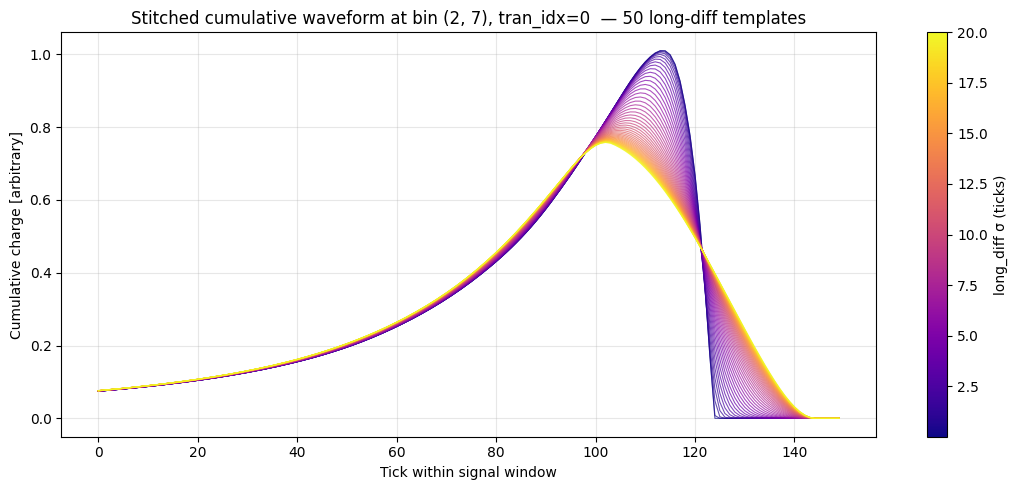

In [4]:

# Plot waveform at a chosen (ix, iy) bin for every longitudinal diffusion template.
# response_template shape: (n_long, n_tran, Nx, Ny, sig_len)
# params.long_diff_template holds the sigma values (n_long,).
#
# Stitching: response_cum[i_long, ix, iy, Nt_cum-2] is the prefix sum of all ticks
# *before* the signal window (ticks 0..Nt_full-sig_len-1).  Adding it to the
# within-window cumsum gives the correct absolute running total.
# Note: response_cum is stored for tran[0] only; other tran_idx use the same offset
# as an approximation (total charge is conserved, only spatial distribution differs).

test_ix, test_iy = 2, 7   # spatial bin (change as needed)
test_tran_idx    = 0        # tran template index (0 = sigma_T ~ 0)

n_long, n_tran, Nx, Ny, sig_len_rt = response_template.shape
Nt_cum_rt = params.response_cum.shape[-1]   # = Nt_full - sig_len + 1
long_sigmas = np.array(params.long_diff_template)   # (n_long,)
t_axis = np.arange(sig_len_rt)

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.plasma
norm_c = plt.Normalize(vmin=long_sigmas.min(), vmax=long_sigmas.max())

for i_long, sigma_l in enumerate(long_sigmas):
    wf = np.array(response_template[i_long, test_tran_idx, test_ix, test_iy])
    # Prefix sum = cumsum value just before the signal window starts.
    # response_cum[i_long, ix, iy, Nt_cum-2] = sum of ticks [0 .. Nt_full-sig_len-1].
    # Guard against Nt_cum==1 (signal covers the whole waveform → offset = 0).
    if Nt_cum_rt >= 2:
        prefix = float(params.response_cum[i_long, test_ix, test_iy, Nt_cum_rt - 2])
    else:
        prefix = 0.0
    stitched = prefix + wf.cumsum()
    ax.plot(t_axis, stitched, color=cmap(norm_c(sigma_l)), lw=0.8, alpha=0.7)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_c)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='long_diff σ (ticks)')

ax.set_title(
    f"Stitched cumulative waveform at bin ({test_ix}, {test_iy}), tran_idx={test_tran_idx}  "
    f"— {n_long} long-diff templates"
)
ax.set_xlabel("Tick within signal window")
ax.set_ylabel("Cumulative charge [arbitrary]")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


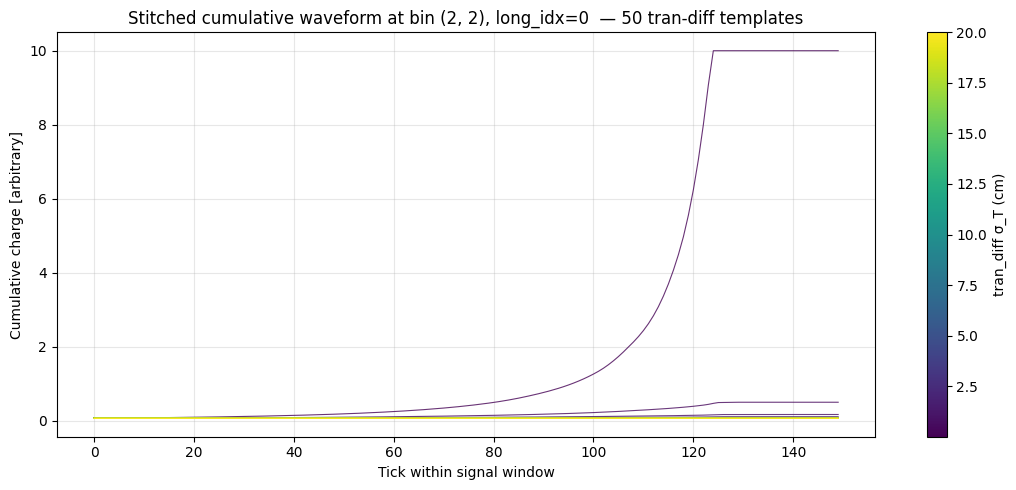

In [6]:

# Same as cell 4 but sweeping over tran_diff templates at a fixed long_diff index.
# response_template shape: (n_long, n_tran, Nx, Ny, sig_len)
# params.tran_diff_template holds the sigma_T values (n_tran,).

test_ix, test_iy  = 2, 2   # spatial bin (same as cell 4)
test_long_idx     = 0       # long_diff template index (0 = no longitudinal diffusion)

tran_sigmas = np.array(params.tran_diff_template)   # (n_tran,)
t_axis = np.arange(sig_len_rt)

fig, ax = plt.subplots(figsize=(11, 5))
cmap = plt.cm.viridis
norm_t = plt.Normalize(vmin=tran_sigmas.min(), vmax=tran_sigmas.max())

for i_tran, sigma_t in enumerate(tran_sigmas):
    wf = np.array(response_template[test_long_idx, i_tran, test_ix, test_iy])
    # Prefix from response_cum (stored for tran[0] only; used as a shared baseline).
    if Nt_cum_rt >= 2:
        prefix = float(params.response_cum[test_long_idx, test_ix, test_iy, Nt_cum_rt - 2])
    else:
        prefix = 0.0
    stitched = prefix + wf.cumsum()
    ax.plot(t_axis, stitched, color=cmap(norm_t(sigma_t)), lw=0.8, alpha=0.8)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_t)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='tran_diff σ_T (cm)')

ax.set_title(
    f"Stitched cumulative waveform at bin ({test_ix}, {test_iy}), long_idx={test_long_idx}  "
    f"— {len(tran_sigmas)} tran-diff templates"
)
ax.set_xlabel("Tick within signal window")
ax.set_ylabel("Cumulative charge [arbitrary]")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Reference 1: Semi-analytical Integration (Current Method)
This uses `density_2d` to calculate weights for each bin in a spatial grid.

In [2]:
def get_semi_analytical_wf(lut, x0, y0, sigma, params):
    nb_bins = params.nb_tran_diff_bins
    nb_bins_sym = (nb_bins - 1) // 2
    width = params.pixel_pitch / params.nb_sampling_bins_per_pixel
    
    bins = jnp.linspace(-nb_bins_sym * width, (nb_bins_sym + 1) * width, nb_bins + 1)
    
    # x0, y0 are relative to the central bin center
    weights = density_2d(bins, jnp.array([x0]), jnp.array([y0]), jnp.array([sigma]))[0]
    
    # Now we need to look up these bins in the LUT
    # For simplicity in this notebook, we assume the LUT is large enough
    # and centered correctly.
    Nx, Ny, Nt = lut.shape
    cx, cy = Nx // 2, Ny // 2
    
    wf = jnp.zeros(Nt)
    for i in range(nb_bins):
        for j in range(nb_bins):
            # bin shift from center
            ix = cx + (i - nb_bins_sym)
            iy = cy + (j - nb_bins_sym)
            wf += weights[i, j] * lut[ix, iy]
            
    return wf

## Reference 2: MC Sampling
Ground truth by sampling many points from the 2D Gaussian.

In [3]:
def get_mc_wf(lut, x0, y0, sigma, params, n_samples=50000, seed=42):
    key = jax.random.PRNGKey(seed)
    width = params.pixel_pitch / params.nb_sampling_bins_per_pixel
    
    # Sample offsets
    offsets = jax.random.normal(key, (n_samples, 2)) * sigma
    pos = jnp.array([x0, y0]) + offsets
    
    # Convert positions to LUT bin indices
    Nx, Ny, Nt = lut.shape
    cx, cy = Nx // 2, Ny // 2
    
    # Bin index = center + floor(pos / width)
    ix = (cx + jnp.floor(pos[:, 0] / width + 0.5)).astype(int)
    iy = (cy + jnp.floor(pos[:, 1] / width + 0.5)).astype(int)
    
    # Clip to be safe
    ix = jnp.clip(ix, 0, Nx - 1)
    iy = jnp.clip(iy, 0, Ny - 1)
    
    # Look up and average
    wfs = lut[ix, iy]
    return jnp.mean(wfs, axis=0)

## Proposed: Transverse Templating
Pre-convolve the raw LUT with 2D Gaussian kernels of different $\sigma_T$ widths.

In [ ]:

def _conv_lut_spatial(lut, kernel_2d):
    # Vectorized 2D conv over (Nx, Ny) for each time bin channel.
    def _conv_one(tplane):
        return jax.scipy.signal.convolve2d(
            tplane, kernel_2d, mode="same", boundary="fill"
        )
    return jax.vmap(_conv_one, in_axes=2, out_axes=2)(lut)

def create_tran_diff_templates(lut, sigma_values, params):
    Nx, Ny, Nt = lut.shape
    width = params.pixel_pitch / params.nb_sampling_bins_per_pixel
    
    templates = []
    for sigma in sigma_values:
        if sigma == 0:
            templates.append(lut)
            continue
            
        extent = int(4 * sigma / width) + 1
        x = jnp.arange(-extent, extent + 1) * width
        X, Y = jnp.meshgrid(x, x)
        kernel = jnp.exp(-(X**2 + Y**2) / (2 * sigma**2))
        kernel = kernel / jnp.sum(kernel)
        
        template = _conv_lut_spatial(lut, kernel)
        templates.append(template)
        print(f"Created template for sigma_T = {sigma:.4f} cm")
        
    return jnp.stack(templates)

# params.tran_diff_template is the primary source of truth: array of sigma_T in cm.
# response_template already has shape (n_long, n_tran, Nx, Ny, sig_len) with
# n_tran = len(params.tran_diff_template).
sigma_t_values = jnp.asarray(params.tran_diff_template)  # (n_tran,) in cm

if response_template.ndim == 5:
    tran_templates = response_template[0]   # (n_tran, Nx, Ny, sig_len)
    print(f"Using pre-computed tran templates: {tran_templates.shape}")
    print(f"sigma_T values (cm): {np.array(sigma_t_values).round(4)}")
else:
    # Fallback: convolve raw_lut (full Nt) on the fly.
    tran_templates = create_tran_diff_templates(jnp.array(raw_lut), sigma_t_values, params)
    print(f"Computed tran templates on-the-fly: {tran_templates.shape}")


Using pre-computed tran templates: (12, 45, 45, 150)


## Comparison Logic
We will pick a test $\sigma_T$ and $(x, y)$ position, and compare the three methods.

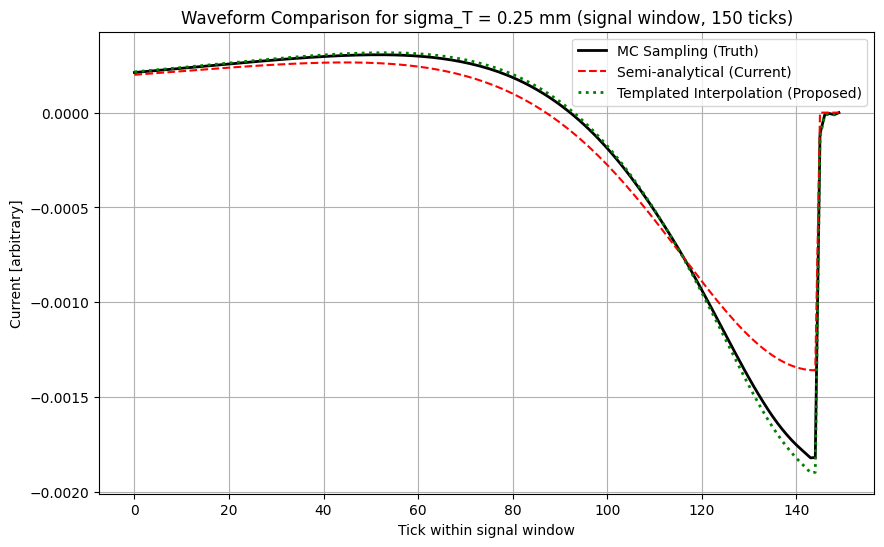

Max Diff (Semi vs MC):      4.63e-04
Max Diff (Templated vs MC): 7.84e-05


In [5]:
test_sigma = 0.25 # mm
test_x, test_y = 0.02, -0.18 # mm, relative to bin center

# MC and semi-analytical use the full raw_lut (Nt_full ticks); we compare on the
# last sig_len ticks which is exactly the signal window stored in tran_templates.
wf_semi_full = get_semi_analytical_wf(raw_lut, test_x, test_y, test_sigma, params)
wf_mc_full   = get_mc_wf(raw_lut, test_x, test_y, test_sigma, params)
wf_semi = wf_semi_full[-sig_len:]
wf_mc   = wf_mc_full[-sig_len:]

# Templated interpolation — tran_templates has shape (n_tran, Nx, Ny, sig_len)
def get_templated_wf(templates, sigma_vals, x0, y0, sigma, params):
    # 1. Interpolate between sigma templates (linear)
    idx = jnp.searchsorted(sigma_vals, sigma)
    idx = jnp.clip(idx, 1, len(sigma_vals) - 1)
    
    s0, s1 = sigma_vals[idx-1], sigma_vals[idx]
    w1 = (sigma - s0) / (s1 - s0)
    w0 = 1.0 - w1
    
    interp_lut = w0 * templates[idx-1] + w1 * templates[idx]  # (Nx, Ny, sig_len)
    
    # 2. Look up spatial position (nearest bin)
    width = params.pixel_pitch / params.nb_sampling_bins_per_pixel
    Nx, Ny = interp_lut.shape[:2]
    cx, cy = Nx // 2, Ny // 2
    
    ix = (cx + jnp.floor(x0 / width + 0.5)).astype(int)
    iy = (cy + jnp.floor(y0 / width + 0.5)).astype(int)
    
    return interp_lut[ix, iy]  # (sig_len,)

wf_templated = get_templated_wf(tran_templates, sigma_t_values, test_x, test_y, test_sigma, params)

t_axis = jnp.arange(sig_len)
plt.figure(figsize=(10, 6))
plt.plot(t_axis, wf_mc,       'k-',  lw=2, label='MC Sampling (Truth)')
plt.plot(t_axis, wf_semi,     'r--',       label='Semi-analytical (Current)')
plt.plot(t_axis, wf_templated,'g:',  lw=2, label='Templated Interpolation (Proposed)')
plt.title(f"Waveform Comparison for sigma_T = {test_sigma} mm (signal window, {sig_len} ticks)")
plt.xlabel("Tick within signal window")
plt.ylabel("Current [arbitrary]")
plt.legend()
plt.grid(True)
plt.show()

print(f"Max Diff (Semi vs MC):      {jnp.max(jnp.abs(wf_semi - wf_mc)):.2e}")
print(f"Max Diff (Templated vs MC): {jnp.max(jnp.abs(wf_templated - wf_mc)):.2e}")
